# Задача
Проанализировать и опеределить какой тест на беременность лучше

# Структура данных

- y_true - правильные ответы:
  - 0 - беременности нет
  - 1 - беременность есть
- y_pred1 - ответ первого теста
- y_pred2 - овтет второго теста

# Загрузка данных

In [28]:
import pandas as pd

In [29]:
! pip install gdown==v4.6.3

In [30]:
! gdown 1T-nWdDdnjNWHjuwHvFaTQqlQ8ewz9hYI

Downloading...
From: https://drive.google.com/uc?id=1T-nWdDdnjNWHjuwHvFaTQqlQ8ewz9hYI
To: /content/pregnancy.csv
100% 60.0k/60.0k [00:00<00:00, 72.7MB/s]


In [31]:
df = pd.read_csv('/content/pregnancy.csv')

In [32]:
len(df)

10000

In [33]:
df.head()

,y_true,y_pred1,y_pred2
0,0,0,0
1,1,1,1
2,1,1,1
3,0,1,0
4,1,1,1


In [34]:
from sklearn.metrics import recall_score

In [35]:
# sensitivity первого теста (сколько беременных "поймал" тест)
recall_score(df['y_true'], df['y_pred1'])

0.9901671583087512

In [36]:
# sensitivity второго теста (сколько беременных "поймал" тест)
recall_score(df['y_true'], df['y_pred2'])

0.9508357915437562

In [37]:
# specificity первого теста
recall_score(df['y_true'], df['y_pred1'], pos_label = 0)

0.9084435401831129

In [38]:
# specificity второго теста
recall_score(df['y_true'], df['y_pred2'], pos_label = 0)

0.9491353001017294

# Confusion matrix (матрица ошибок)

In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

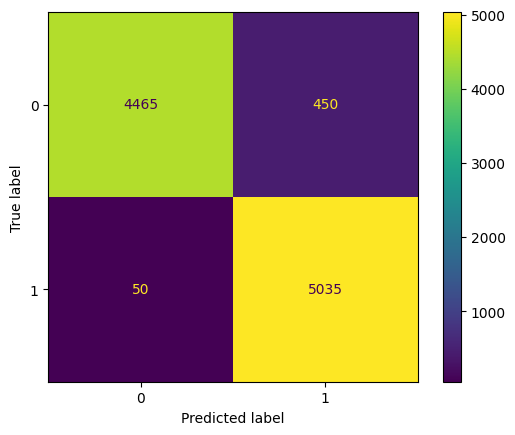

In [40]:
cm = confusion_matrix(df['y_true'], df['y_pred1'])
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot()

In [41]:
confusion_matrix(df['y_true'], df['y_pred1'])

array([[4465,  450],
       [  50, 5035]])

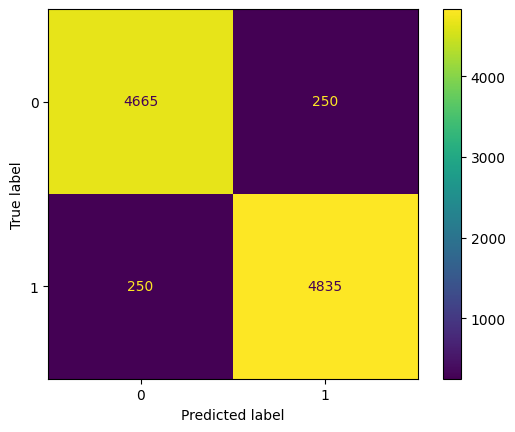

In [42]:
cm = confusion_matrix(df['y_true'], df['y_pred2'])
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot()

In [43]:
confusion_matrix(df['y_true'], df['y_pred2'])

array([[4665,  250],
       [ 250, 4835]])

Приоритет — sensitivity, потому что пропустить беременность (FN) опаснее, чем дать ложную тревогу (FP). У Теста 1 sensitivity выше: 0.990 против 0.951, то есть он пропускает 50 беременных против 250 у Теста 2. Поэтому Тест 1 лучше, несмотря на более низкую specificity.



# Таблица sens и spec

In [44]:
df.head()

,y_true,y_pred1,y_pred2
0,0,0,0
1,1,1,1
2,1,1,1
3,0,1,0
4,1,1,1


In [45]:
df['test1'] = df['y_true'] == df['y_pred1']
df['test2'] = df['y_true'] == df['y_pred2']

In [47]:
result = df.groupby('y_true')[['test1', 'test2']].mean()
result['label'] = ['specificity', 'sensitivity']
result

,test1,test2,label
y_true,,,
0,0.908444,0.949135,specificity
1,0.990167,0.950836,sensitivity
